Провести разведочный анализ данных о продажах кофейного автомата: 
  *  оценить качество и полноту данных,
  *  изучить динамику транзакций и выручки,
  *  определить структуру спроса,
  *  выявить временные закономерности и аномалии,
  *  сформулировать гипотезы для дальнейшего анализа.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df=pd.read_csv('../data/index_1.csv')
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 405.1 KB


In [23]:
df_null = df[df.isna().any(axis=1)]
df_null.head(30)

,date,datetime,cash_type,card,money,coffee_name
12,2024-03-02,2024-03-02 10:30:35.668,cash,NaN,40.0,Latte
18,2024-03-03,2024-03-03 10:10:43.981,cash,NaN,40.0,Latte
41,2024-03-06,2024-03-06 12:30:27.089,cash,NaN,35.0,Americano with Milk
46,2024-03-07,2024-03-07 10:08:58.945,cash,NaN,40.0,Latte
49,2024-03-07,2024-03-07 11:25:43.977,cash,NaN,40.0,Latte
60,2024-03-09,2024-03-09 11:49:37.292,cash,NaN,40.0,Hot Chocolate
74,2024-03-10,2024-03-10 07:44:18.538,cash,NaN,30.0,Americano
75,2024-03-10,2024-03-10 07:45:29.441,cash,NaN,35.0,Americano with Milk
76,2024-03-10,2024-03-10 10:06:02.960,cash,NaN,40.0,Latte
78,2024-03-10,2024-03-10 17:51:03.048,cash,NaN,35.0,Americano with Milk


In [24]:
print(f'Всего строк с null: {len(df_null)} из них с оплатой cash:{len(df_null[df_null['cash_type']=='cash'])}')

Всего строк с null: 89 из них с оплатой cash:89


(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

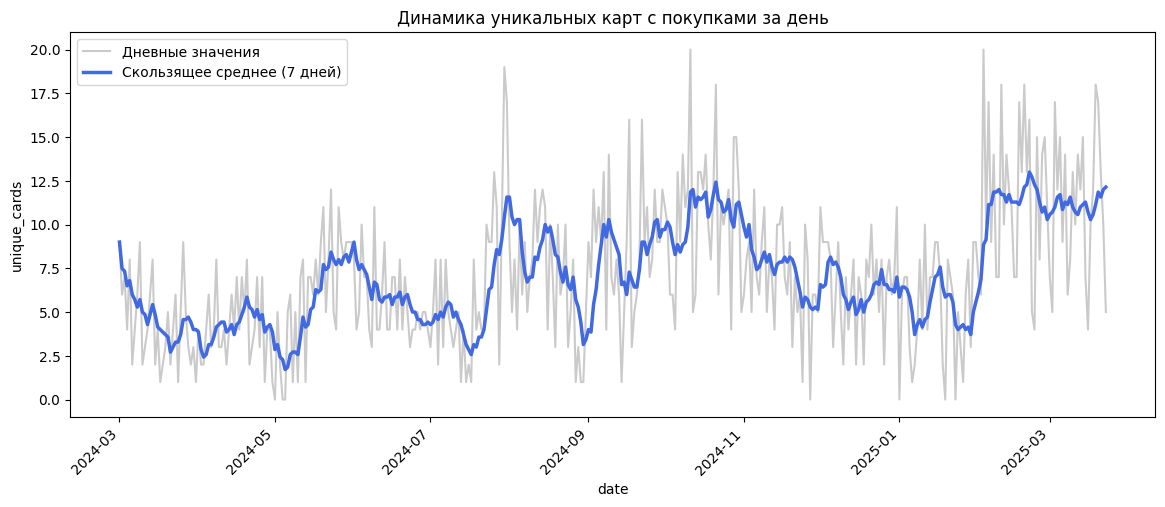

In [25]:
df['date']=pd.to_datetime(df['date'])
daily_unique_cards = (
    df.set_index('date')
      .resample('D')
      .agg(unique_cards=('card', 'nunique'))
)

daily_unique_cards['rolling_7d']=(
    daily_unique_cards['unique_cards'].rolling('7D',min_periods=1).mean()
)

plt.figure(figsize=(14,5))
sns.lineplot(data=daily_unique_cards, x='date',y='unique_cards',label='Дневные значения', color='gray', alpha=0.41)
sns.lineplot(data=daily_unique_cards, x='date',y='rolling_7d',label='Скользящее среднее (7 дней)', color='royalblue', linewidth=2.5)

plt.title("Динамика уникальных карт с покупками за день")
plt.xticks(rotation=45,ha='right')

(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

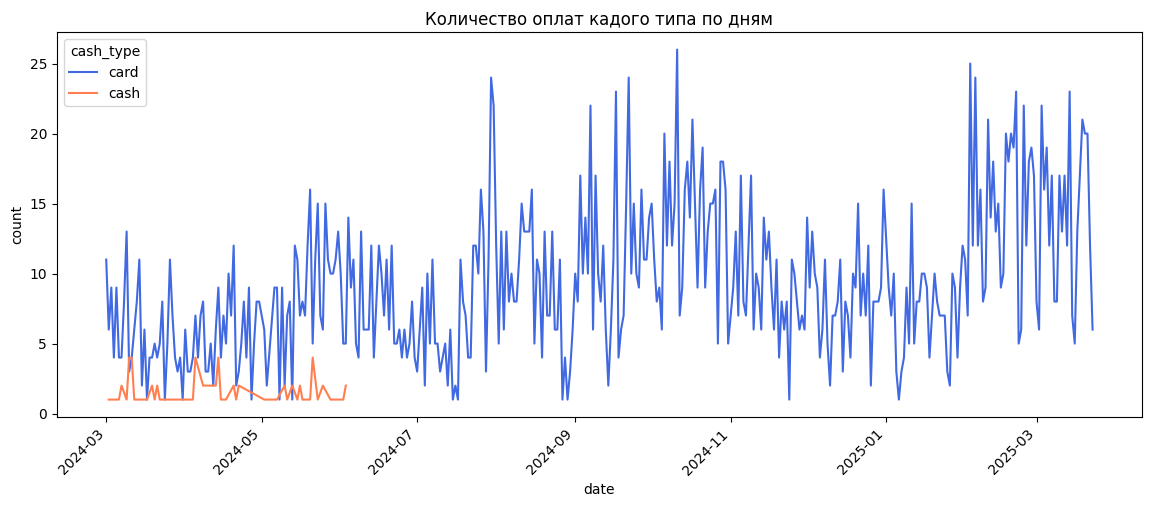

In [26]:
payments_daily=df.groupby(['date','cash_type']).size().reset_index(name='count')
payments_daily['date']=pd.to_datetime(payments_daily['date'])

plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат кадого типа по дням')
plt.xticks(rotation=45, ha='right')

(array([19783., 19797., 19814., 19828., 19844., 19858., 19875., 19889.,
        19905.]),
 [Text(19783.0, 0, '2024-03-01'),
  Text(19797.0, 0, '2024-03-15'),
  Text(19814.0, 0, '2024-04-01'),
  Text(19828.0, 0, '2024-04-15'),
  Text(19844.0, 0, '2024-05-01'),
  Text(19858.0, 0, '2024-05-15'),
  Text(19875.0, 0, '2024-06-01'),
  Text(19889.0, 0, '2024-06-15'),
  Text(19905.0, 0, '2024-07-01')])

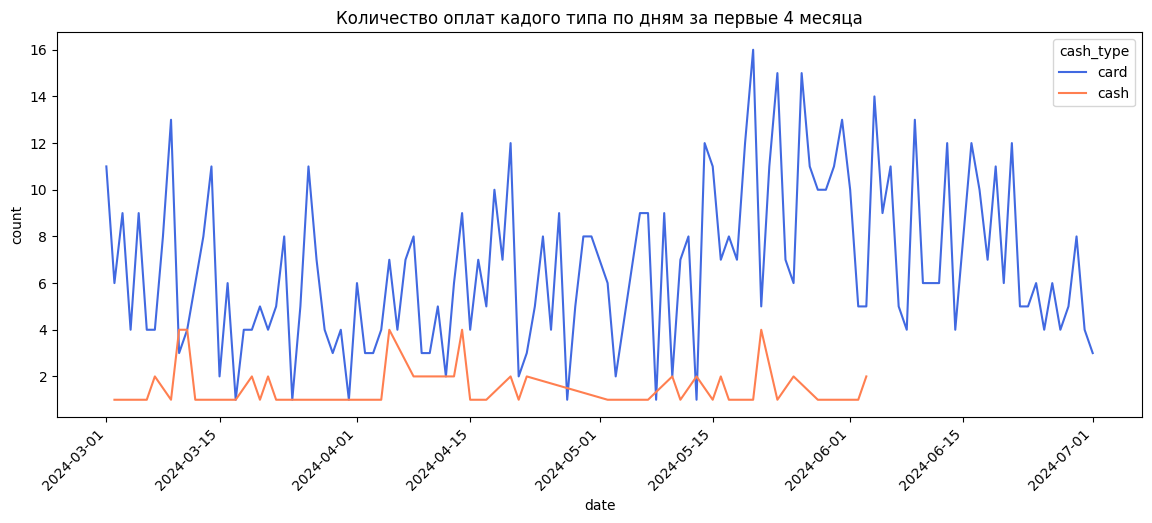

In [27]:
payments_daily_4m=payments_daily[payments_daily['date']<='2024-07-01']
plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily_4m,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат кадого типа по дням за первые 4 месяца')
plt.xticks(rotation=45, ha='right')

In [28]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [29]:
df['date'] = pd.to_datetime(df['date'])
start_date = df['date'].min()
cash_end_date = df[df['cash_type'] == 'cash']['date'].max()

period_dates = pd.date_range(start_date, cash_end_date)
all_dates = pd.date_range(start_date, df['date'].max())

cash_period_data = (df[df['cash_type'] == 'cash']
                    .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                    .reindex(period_dates, fill_value=0)
                    .cumsum())

card_period_data = (df[(df['cash_type'] == 'card') & (df['date'] <= cash_end_date)]
                    .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                    .reindex(period_dates, fill_value=0)
                    .cumsum())

card_all_time_data = (df[df['cash_type'] == 'card']
                      .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                      .reindex(all_dates, fill_value=0)
                      .cumsum())


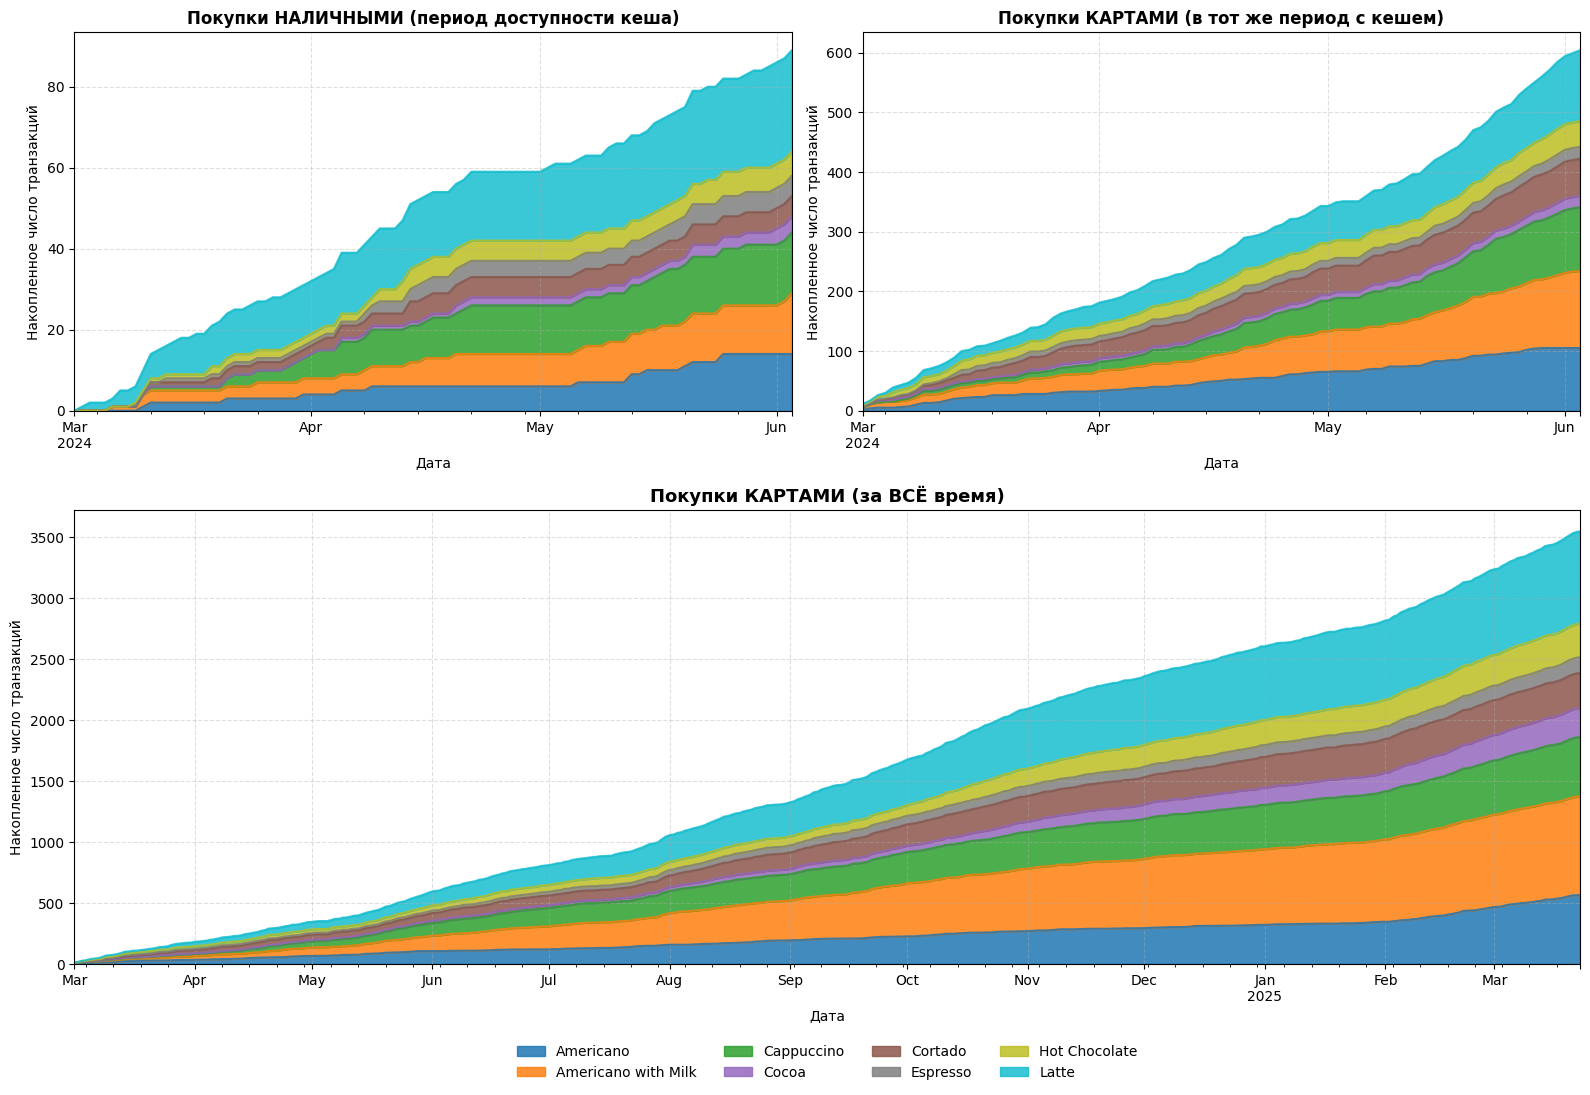

In [30]:
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# --- График 1 (Слева сверху: Наличные) ---
cash_period_data.plot.area(ax=ax1, alpha=0.85, colormap='tab10', legend=False)
ax1.set_title('Покупки НАЛИЧНЫМИ (период доступности кеша)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Накопленное число транзакций')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- График 2 (Справа сверху: Карты за тот же период) ---
card_period_data.plot.area(ax=ax2, alpha=0.85, colormap='tab10', legend=False)
ax2.set_title('Покупки КАРТАМИ (в тот же период с кешем)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Накопленное число транзакций')
ax2.grid(True, linestyle='--', alpha=0.4)

# --- График 3 (Внизу: Карты за ВСЁ время) ---
card_all_time_data.plot.area(ax=ax3, alpha=0.85, colormap='tab10')
ax3.set_title('Покупки КАРТАМИ (за ВСЁ время)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Дата')
ax3.set_ylabel('Накопленное число транзакций')
ax3.grid(True, linestyle='--', alpha=0.4)

ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


  > После 3 июня в датасете отсутствуют наличные операции. Это может отражать
  > изменение способа оплаты или сбора данных, но установить причину по имеющимся
  > полям невозможно.